# Tutorial 1: Integration of simulated spatial tri-omics dataset.

This notebook provides a step-by-step guide on how to obtain joint embeddings on the simulated spatial tri-omics dataset.

In [1]:
# Import required libraries and dependencies
import torch
import warnings
import scanpy as sc
import matplotlib.pyplot as plt

from maple.model import *
from maple.utils import *
from maple.preprocess import *
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (homogeneity_score, completeness_score, mutual_info_score, normalized_mutual_info_score,
                             adjusted_mutual_info_score, fowlkes_mallows_score, adjusted_rand_score)

# Initialize global settings
seed = 11451
fix_seed(seed)
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
warnings.filterwarnings('ignore', category=UserWarning)

Global random seed set to: 11451.


In [2]:
# Load the simulated spatial tri-omics dataset
adata_rna = sc.read_h5ad('../data/simulated/adata_rna.h5ad')
adata_pro = sc.read_h5ad('../data/simulated/adata_pro.h5ad')
adata_atac = sc.read_h5ad('../data/simulated/adata_atac.h5ad')

# Preprocess the RNA data
adata_rna.layers['counts'] = adata_rna.X.copy()
sc.pp.normalize_total(adata_rna, target_sum=1e4)
sc.pp.log1p(adata_rna)
sc.pp.scale(adata_rna)
adata_rna.obsm['X_feat'] = compute_pca(adata_rna.X, 40)

# Preprocess the protein data
adata_pro.layers['counts'] = adata_pro.X.copy()
clr_normalize_each_cell(adata_pro)
sc.pp.scale(adata_pro)
adata_pro.obsm['X_feat'] = compute_pca(adata_pro.X, 40)

# Preprocess the ATAC data
adata_atac.layers['counts'] = adata_atac.X.copy()
compute_lsi(adata_atac, 40)
scaler = StandardScaler()
adata_atac.obsm['X_feat'] = scaler.fit_transform(adata_atac.obsm['X_feat'])

# Inspect the processed data
adata_rna, adata_pro, adata_atac

(AnnData object with n_obs × n_vars = 1296 × 1000
     obs: 'annotation'
     var: 'gene_symbol', 'mean', 'std'
     uns: 'annotation_colors', 'log1p'
     obsm: 'spatial', 'X_feat'
     layers: 'counts',
 AnnData object with n_obs × n_vars = 1296 × 100
     obs: 'annotation'
     var: 'gene_symbol', 'mean', 'std'
     uns: 'annotation_colors'
     obsm: 'spatial', 'X_feat'
     layers: 'counts',
 AnnData object with n_obs × n_vars = 1296 × 1000
     obs: 'annotation'
     var: 'gene_symbol'
     uns: 'annotation_colors'
     obsm: 'spatial', 'X_feat'
     layers: 'counts')

In [3]:
# Create a MAPLE model and initialize it
maple = MAPLE(
        adata_rna=adata_rna,
        adata_pro=adata_pro,
        adata_atac=adata_atac,
        dataset_type='sim',
        n_spat_neighbors=8,
        max_patience=50,
        weight_decay=0.002,
        device=device
    )

# Train the MAPLE model
maple.train_modal()

The spatial, feature, and joint graphs have been successfully generated.
The simulated gene ontology graph has been successfully generated.
The spatial, feature, and joint graphs have been successfully generated.
The spatial, feature, and joint graphs have been successfully generated.
The simulated transcription factor graph has been successfully generated.
The simulated cross-modal translational graph has been successfully generated.
The simulated cross-modal regulatory graph has been successfully generated.


Training:  14%|█▍        | 288/2000 [00:05<00:33, 50.76it/s, recon_loss_rna=0.811843, recon_loss_pro=0.557822, recon_loss_atac=0.764339, recon_loss_atac_hvp=39.364731, trans_loss=0.999228, reg_loss=0.999228, total_loss=2.134005]

Early stopping triggered at epoch 289.
Total training time: 5.69 seconds.
Peak GPU memory usage: 123.89 MB.


In [4]:
# Prepare a new AnnData for unified qualitative and quantitative analysis
adata = adata_rna.copy()

# Extract the joint embeddings
with torch.no_grad():
    maple.eval()
    results = maple.forward()
    adata.obsm['maple_emb'] = results['joint_emb'].cpu().numpy()

# Perform Leiden clustering on the joint embeddings
optimize_leiden(adata=adata, n_clusters=5, used_obsm='maple_emb',
                add_obs='maple_leiden', res_min=0.01, res_max=0.5)

Current resolution is 0.2550, found 7 clusters.
Current resolution is 0.1325, found 5 clusters.
Success: Leiden found 5 clusters at resolution 0.1325 (Attempt 2).


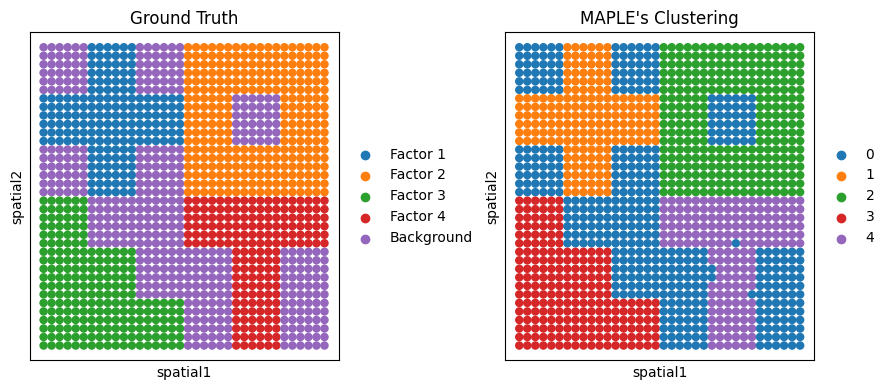

In [5]:
# Visualize spatial ground truth and MAPLE's clustering
fig, ax_list = plt.subplots(1, 2, figsize=(9, 4))

sc.pl.embedding(adata, basis='spatial', title='Ground Truth', color='annotation', ax=ax_list[0], s=150, show=False)
sc.pl.embedding(adata, basis='spatial', title='MAPLE\'s Clustering', color='maple_leiden', ax=ax_list[1], s=150, show=False)

plt.tight_layout(w_pad=0.5)
plt.show()

In [6]:
# Calculate supervised metrics for spatial domain segmentation
GT_labels = adata.obs['annotation']
cluster_labels = adata.obs['maple_leiden']

Homo = homogeneity_score(GT_labels, cluster_labels)
Comp = completeness_score(GT_labels, cluster_labels)
MI = mutual_info_score(GT_labels, cluster_labels)
NMI = normalized_mutual_info_score(GT_labels, cluster_labels)
AMI = adjusted_mutual_info_score(GT_labels, cluster_labels)
FMI = fowlkes_mallows_score(GT_labels, cluster_labels)
ARI = adjusted_rand_score(GT_labels, cluster_labels)

print(f'Homo: {Homo:.4f}, Comp: {Comp:.4f}, MI: {MI:.4f}, NMI: {NMI:.4f}, AMI: {AMI:.4f}, FMI: {FMI:.4f}, ARI: {ARI:.4f}.')

Homo: 0.9887, Comp: 0.9904, MI: 1.5299, NMI: 0.9895, AMI: 0.9895, FMI: 0.9936, ARI: 0.9917.
